# PRÁCTICA 2 PLN
# Desarrollo de una aplicación de Procesamiento del Lenguaje Natural

Alumnos:

Javier García Fernández

Miguel Ángel Véliz Ayala

## 1. Compilación del corpus y uso de procesamiento léxico

## Paso 1: Crear una Aplicación en Reddit

  Lo primero que vamos a hacer en este proyecto es “Crear una aplicación” en Reddit para acceder a la API y poder descargar datos para nuestra práctica.
  <img src="files/crear_app_reddit.jpg" alt='"Crear una aplicación"' width="300"/>

  Rellenamos el formulario como se muestra a continuación y creamos la aplicación:

  <img src="files/formulario_reddit.jpg" alt='Formulario Reddit' width="300"/>

Tras esto, ya podemos usar nuestro script de uso personal de 14 caracteres y nuestra clave secreta de 27 caracteres para conectarnos a la API y comenzar con el proyecto.

<img src="files/autorización_reddit.jpg" alt='Autorización Reddit' width="300"/>

## Paso 2: Obtener instancias de Reddit

Para acceder a los datos de Reddit desde Python vamos a emplear *Praw* (Python Reddit API Wrapper), una librería de Python que nos permite interactuar con Reddit de forma sencilla.

In [ ]:
# Instalamos praw
!pip install praw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 6.2 MB/s eta 0:00:00


In [ ]:
#pip install pyspellchecker

Configuramos una conexión a la API de Reddit usando la librería *Praw* para poder acceder a contenido público de la plataforma. A partir de esta conexión, ya podemos empezar a extraer y analizar contenido de Reddit de forma automatizada desde Python.

In [ ]:
# Importamos las librerías que vamos a necesitar a lo largo de este apartado
import praw
import json
import time
import re
from datetime import datetime, timedelta
import random

# Configuración de la App Reddit: Nos conectamos a la API de Reddit con la función praw.Reddit() completando los
# parámetros con los valores obtenidos al crear la aplicación: (ID de cliente, clave secreta y usuario)

reddit = praw.Reddit(
    client_id="CLIENT_ID",          # ESTOS 3 PARAMETROS DEBEN SER REMPLAZADOS 
    client_secret="CLIENT_SECRET",  # POR LOS VALORES OBTENIDOS AL CREAR LA APLICACIÓN EN REDDIT
    user_agent="USER_AGENT"
)

"""Específicamente, estamos autentificándonos como una aplicación de sólo lectura mediante un 'cliente_id', 'client secret'
y un 'user_agent', lo cual es suficiente para lo que necesitamos hacer, que es extraer y analizar publicaciones de subreddits, comentarios,
información de los usuarios etc."""

"Específicamente, estamos autentificándonos como una aplicación de sólo lectura mediante un 'cliente_id', 'client secret'\ny un 'user_agent', lo cual es suficiente para lo que necesitamos hacer, que es extraer y analizar publicaciones de subreddits, comentarios,\ninformación de los usuarios etc."

### Subreddits

La temática elegida para la recolección de datos ha sido `deportes` porque consideramos que las conversaciones, opiniones y debates en esta ámbitos están siempre a la orden del día y por ello es un tema transversal que abarca múltiples disciples y contará con muchos usuarios activos en Reddit. Hemos seleccionado siete subreddits especialziados,cada uno centrado en una disciplina o enfoque diferente del ámbito deportivo: `sports`(general), `soccer`(fútbol), `nba`(baloncesto estadounidense), `formula1`(automovilismo), `hockey`, `criquet` y `nfl`(fútbol americano). Esta selección permite cubrir una variedad de deportes pupulares a nivel internacional, asegurando diversidad temática y linguística dentro del mismo campo de estudio.

In [ ]:
# Lista de subreddits deportivos
subreddits = ["sports", "soccer", "nba", "formula1", "hockey", "cricket", "nfl"]

## Preprocesamiento y Curación del Corpus

La materia prima de nuestro modelo es tanto el texto de hilos de los subreddis escogidos como el de los comentarios de esos hilos. Sin embargo, para asegurar que los datos de entrada del modelo sean limpios, variados y de calidad, debemos llevar a cabo un preprocesamiento del corpus.


### 1. Distribución temporal de comentarios e hilos

  El primer paso es definir un rango temporal para evitar sesgos temportales en los comentarios recolectados, es decir, evitar que todas las publicaciones provengan del mismo día. Para ello, hemos establecido un rango de una semana (7 días) calculando las fechas de inicio y fin en formato *timestamp UNIX* que serán utilizadas para filtrar contenido durante la extracción con la API de Reddit.

### 2. Filtrado de Comentarios poco informativos

  Antes de procesar los textos, debemos descartar aquellos comentarios que consideramos que aportan poco valor semántico o informativa para la tarea que queremos realizar (clasificación).

  Para este proceso hemos implementado la función `is_valid_comment` que se encarga de decidir si un comentario de entrada es adecuado para incluirlo a nuestro conjunto de datos o si debemos descartarlo y seguir buscando.

  En esta función se aplican varios filtros: se descartan comentarios que no alcanzan un número mínimo de palabras (min_comment_len), comentarios compuestos mayoritariamente por emojis, los que solamente están formados por enlaces o direcciones de correo y aquellos con un número muy bajo de palabras únicas para evitar contenido repetitivo o muy poco variado.

### 3. Preprocesamiento del texto

  El siguiente paso, una vez tenemos seleccionado un comentario válido, es realizar una normalización del texto para facilitar su análisis. Esto consiste en la conversión a minúsculas del texto, eliminar los signos de puntuación (ya que son irrelevantes para la tarea de clasificación por tipo de subreddit), eliminar espacios extra y la tokenización del texto en el que cada token es una palabra (Whitespace tokenization) para facilitar su tratamiento posterior.

  Es importante destacar que vamos a eliminar stopwords, ya que el enfoque del modelo no se basa en representaciones tipo "bag of words", sino que busca preservar el contexto completo de la oración, donde las stopwords pueden tener un rol semántico relevante.

### 4. Corrección ortográfica con Hunspell

 Finalmente, para mejorar la calidad del corpus, hemos decidido realizar una corrección ortográfica automática usando la biblioteca Hunspell. Hunspell se va a encargar de aplicar la corrección palabra por palabra sobre el texto ya tokenizado y sustituir las palabras mal escritas por la primera sugerencia ofrecida por Hunspell (si la hay) reconstruyendo el texto corregido uniendo todas las palabras corregidas.


En conjunto, este pipeline garantiza que solo los comentarios relevantes, limpios y bien escritos sean añadidos al corpus, mejorando así la calidad de los datos para la clasificación de subreddits posterior.


In [ ]:
### 1. Distribuir hilos y comentarios en el tiempo ###

# Definir un rango de fechas (por ejemplo, última semana): para evitar que todos sean del mismo día
# Fechas de inicio y fin
DAYS_RANGE = 7
end_date = datetime.utcnow()
start_date = end_date - timedelta(days=DAYS_RANGE)
start_timestamp = time.mktime(start_date.timetuple())
end_timestamp = time.mktime(end_date.timetuple())

### 2. FIltrado de comentarios poco informativos ###

# Implementamos una función 'hast_mostly_emojis' para descartar comentarios con
# muy poco valor semántico
!pip install emoji
import emoji

def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')


def has_mostly_emojis(text, threshold=0.5):
    emojis = [char for char in text if char in emoji.EMOJI_DATA]
    return len(emojis) / len(text) > threshold if text else False

# Función para validar comentarios

def is_valid_comment(comment_body, min_comment_len, n_words):

    # Filtrar comentarios muy cortos
    if len(comment_body.split()) < min_comment_len:
        return False

    # Descartar comentarios si tiene solo emojis o muchos emojis
    if has_mostly_emojis(comment_body):
        return False

    # Filtrar comentarios con solo URLs o emails
    if re.match(r'http[s]?://|www\.', comment_body) or re.match(r'.*[\w\.-]+@[\w\.-]+\.\w+', comment_body):
        return False

    # Eliminar si tiene menos de N palabras diferentes
    palabras = set(tokenize(comment_body))
    if len(palabras) < n_words:
        return False
    return True

### 3. Preprocesamiento del texto ###
"""
Antes de la corrección ortográfica del texto, es recomendable preprocesar el texto transformandolo en una forma
que sea más fácil de analizar y procesar.
Vamos a NORMALIZAR el texto:
-> Convertimos todo el texto a minúsculas para evitar que palabras con diferentes capitalizaciones sean tratadas como diferentes.
-> Eliminamos signos de puntuación para que no se procesen caracteres no relevantes
-> Reducimos múltiples espacios a uno solo y eliminamos los espacios del principio y del final
-> Tokenizamos el texto dividiendolo en palabras.
"""

import string

sp_punctuation = string.punctuation + '¿' + '¡'

def remove_punctuation(text): # Elegir si elimino o no puntuación (porque con context embedding si puede ser valiosa)
    punctuationfree="".join([i for i in text if i not in sp_punctuation])
    return punctuationfree

def tolower(text):
    return text.strip().lower()

def tokenize(text):
    return text.split()

def preprocesado(text): # Función que realiza los pasos de preprocesamiento en secuencia
    return tokenize(text)# DECIDIMOS NO ELIMINAR PUNTUACIÓN, NI PASAR A TODO A MINUSCULA, SÓLO TOKENIZAR DE MOMENTO

"""
No vamos a eliminar las stopwords porque en nuestro modelo el contexto es importante, no va a estar basado en BoW ,
por lo que las stopwords puede ser relevantes para entender la estructura de la frase y los matices de significado.

"""
### 4. Corrección automática del texto ###

"""
Vamos a utilizar el corrector ortográfico 'Hunspell' para realizar la corrección ortográfica sobre los textos seleccionados.
Hunspell utiliza diccionarios de palabras válidas (.dic) y archivos de reglas gramaticales y de derivación para el idioma (inglés).
Hemos escogido Hunspell en lugar de SymSpell para conseguir una corrección más precisa y rigurosa

"""
!sudo apt-get install libhunspell-dev
!pip install hunspell

# Instalamos los diccionarios de Hunspell
!sudo apt-get install hunspell-en-us
# Este paquete instala el diccionario y las reglas gramaticales
# La ubicación de los archivos es /usr/share/hunspell/

import hunspell

# Creamos una función para corregir textos
def corrector_ortografico_hunspell(text):
    # Creamos el objeto Hunspell para inglés
    h = hunspell.HunSpell('/usr/share/hunspell/en_US.dic', '/usr/share/hunspell/en_US.aff')

    # Separamos el texto en palabras ya tokenizadas para que corrija cada palabra por separado
    words = preprocesado(text)
    corrected_words = []

    for word in words:
        # Si la palabra está mal escrita, obtener la sugerencia
        if not h.spell(word):
            suggestions = h.suggest(word)
            # Usar la primera sugerencia si existe
            if suggestions:
                corrected_words.append(suggestions[0])
            else:
                corrected_words.append(word)  # Si no hay sugerencias, mantener la palabra original
        else:
            corrected_words.append(word)

    # Finalmente las palabras corregidas se unen para formar el texto corregido
    corrected_text = ' '.join(corrected_words)
    return corrected_text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 11.6 MB/s eta 0:00:00

Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dictionaries-common hunspell-en-us libhunspell-1.7-0 libtext-iconv-perl
Suggested packages:
  ispell | aspell | hunspell wordlist hunspell openoffice.org-hunspell
  | openoffice.org-core
The following NEW packages will be installed:
  dictionaries-common hunspell-en-us libhunspell-1.7-0 libhunspell-dev
  libtext-iconv-perl
0 upgraded, 5 newly installed, 0 to remove and 34 not upgraded.
Need to get 896 kB of archives.
After this operation, 3,130 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libtext-iconv-perl amd64 1.7-7build3 [14.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 dictionaries-common all 1.28.14 [185 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 hunspell-en-us all 1:2020.12.07-2 [280 kB]
Get:4 

### Selección del Conjunto de Datos

Para recolectar y depurar hilos y comentarios de distintos subreddits para construir un corpus representativo, hemos implementado un pipeline que utiliza la biblioteca *Praw* para interactuar con la API de Reddit.

El objetivo es extraer comentarios de diversos hilos de cada uno de los 7 subreddits seleccionados (lista `subreddits`: sports, soccer, nba, formula1, hockey, cricket y nfl), buscando obtener aproximadamente 7000 comentarios que compondrán nuestro conjunto de datos.

Hemos establecido un límite base de 160 hilos por subreddit, con un incremento de 20 hilos adicionales para los subreddits más activos (nba, formula1, hockey, cricket y nfl). Esto nos permite compensar la variabilidad en la actividad entre diferentes comunidades y asegurar un volumen de datos equilibrado.

Además, hemos tomado la decisión de seleccionar un 70% de hilos de cada subreddit con el método `.new` y el 30% restante con el método `.hot`. Con esto pretendemos lograr un balance entre variedad y relevancia. El método `.new` nos permite extraer los hilos más recientes, mientras que `.hot` garantiza obtener los hilos más populares y representativos de esa temática. Por tanto, buscamos mezclar la diversidad temática con lo más representativo de cada comunidad. Al dar mayor peso a `.new`, ampliamos la cobertura y evitamos sesgos hacia "lo que más gusta", favoreciendo una muestra más imparcial. De esta forma, conseguiremos un entrenamiento más realista y un modelo más robusto.

Para cada hilo buscamos extraer 7 comentarios (con algunos casos especiales como sports y soccer donde intentamos obtener 9 comentarios por hilo para compensar su menor actividad). Empleamos un muestreo aleatorio de los comentarios de cada hilo con el objetivo de obtener una representación más equilibrada y no sesgada del contenido. Si simplemente extrajéramos los primeros comentarios, estaríamos priorizando respuestas tempranas que podrían tratar solo unos asuntos concretos y pasaríamos por alto perspectivas valiosas que aparecen más abajo en el hilo. Al seleccionar comentarios de forma aleatoria evitamos ese sesgo temporal y temático, capturando una muestra más diversa para enriquecer nuestro corpus.

Incorporamos flexibilidad en nuestro algoritmo permitiendo aceptar hilos con al menos el 70% de los comentarios objetivo (aproximadamente 5 comentarios por hilo en la mayoría de casos, y 1 menos para sports y soccer). Esto nos permite maximizar la utilización de hilos valiosos que puedan tener ligeramente menos interacción.

Para cada comentario aplicamos la función `is_valid_comment()` que verifica si cumple con nuestros criterios mínimos: al menos 20 caracteres y 15 palabras. Una vez seleccionados todos los comentarios válidos de un hilo, añadimos cada uno a un diccionario 'thread_data' junto con los metadatos del hilo y pasamos cada comentario por la función `corrector_ortografico_hunspell()` para corregir errores ortográficos antes de almacenarlo en el dataset.

Al finalizar la extracción, guardamos todos los hilos y comentarios en archivos JSON individuales para cada subreddit, facilitando así su posterior procesamiento y análisis.

In [ ]:
### Parámetros ###

# Lista de subreddits deportivos
subreddits = ["sports", "soccer", "nba", "formula1", "hockey", "cricket", "nfl"]

# Límite base de hilos y comentarios para todos los subreddits
LIMIT_HILOS_BASE = 160

# Vamos a crear un diccionario para asignar límites específicos a cada subreddit
# Aumentar los subreddits con más actividad para compensar por los que tienen menos
LIMIT_HILOS_POR_SUBREDDIT = {
    "sports": LIMIT_HILOS_BASE,  # Mantener el límite base
    "soccer": LIMIT_HILOS_BASE,  # Mantener el límite base
    "nba": LIMIT_HILOS_BASE + 20,  # Aumentamos específicamente en 20 porque es un subreddit muy activo
    "formula1": LIMIT_HILOS_BASE + 20,  # Aumentamos específicamente en 20 porque es un subreddit muy activo
    "hockey": LIMIT_HILOS_BASE + 20,  # Aumentamos específicamente en 20 porque es un subreddit muy activo
    "cricket": LIMIT_HILOS_BASE + 20,  # Aumentamos específicamente en 20 porque es un subreddit muy activo
    "nfl": LIMIT_HILOS_BASE + 20,  # Aumentamos específicamente en 20 porque es un subreddit muy activo
}

# Número de comentarios por hilo
COMENTARIOS_HILO = 7

# Flexibilidad para aceptar hilos con menos comentarios
MIN_COMENTARIOS_ACEPTABLE = int(COMENTARIOS_HILO * 0.7)

# Valores mínimos para validar un comentario
min_comment_len = 20
n_words = 15

# Inicializamos nuestro conjunto de datos
data = {}

### Programa: Extracción de Comentarios ###

for subreddit in subreddits:
    print(f"Extrayendo datos de r/{subreddit}...")
    data[subreddit] = []

    total_comments = 0

    # Límite específico para este subreddit
    LIMIT_HILOS = LIMIT_HILOS_POR_SUBREDDIT[subreddit]
    LIMIT_NEW_HILOS = int(LIMIT_HILOS * 0.7)  # 70 % de .new
    LIMIT_HOT_HILOS = LIMIT_HILOS - LIMIT_NEW_HILOS  # 30 % de .hot

    ####### --- COMMENTS .new  --- #######
    hilos_new = 0
    # Límite de búsqueda para encontrar más hilos
    for submission in reddit.subreddit(subreddit).new(limit=400):
        # Filtramos los hilos quedándonos sólo con los de la útima semana
        if submission.created_utc < start_timestamp or submission.created_utc > end_timestamp:
            continue

        if hilos_new >= LIMIT_NEW_HILOS:
            break

        # Para sports y soccer, intenta obtener más comentarios por hilo para compensar
        # porque son los subreddits que más cuesta obtener comentarios
        local_comentarios_hilo = COMENTARIOS_HILO
        if subreddit in ["sports", "soccer"]:
            local_comentarios_hilo = COMENTARIOS_HILO + 2

        submission.comments.replace_more(limit=0)
        comments = submission.comments
        comments_thread = len(comments)

        if comments_thread == 0:
            continue

        selected_comments = []
        seen_indices = set()
        attempts = 0
        # Número máximo de intentos para los subreddits con menos hilos
        max_attempts = 300 if subreddit in ["sports", "soccer"] else 200

        while len(selected_comments) < local_comentarios_hilo and attempts < max_attempts:
            attempts += 1
            random_index = random.randint(0, comments_thread - 1)
            if random_index in seen_indices:
                continue
            seen_indices.add(random_index)

            comment = comments[random_index]
            if is_valid_comment(comment.body, min_comment_len, n_words):
                selected_comments.append(comment)

        # Flexibilidad para aceptar hilos para sports y soccer
        min_comments_required = MIN_COMENTARIOS_ACEPTABLE - 1 if subreddit in ["sports", "soccer"] else MIN_COMENTARIOS_ACEPTABLE

        if len(selected_comments) < min_comments_required:
            continue

        thread_data = {
            "flair": submission.link_flair_text,
            "title": submission.title,
            "author": submission.author.name if submission.author else "Anonymous",
            "date": submission.created_utc,
            "score": submission.score,
            "description": submission.selftext,
            "comments": []
        }

        for comment in selected_comments:
            thread_data["comments"].append({
                "user": comment.author.name if comment.author else "Anonymous",
                "comment": corrector_ortografico_hunspell(comment.body),
                "score": comment.score,
                "date": comment.created_utc
            })

        data[subreddit].append(thread_data)
        total_comments += len(selected_comments)
        hilos_new += 1

        # Tiempo de espera adaptativo para no sobrecargar la API
        if subreddit in ["sports", "soccer"]:
            time.sleep(0.3)
        else:
            time.sleep(0.5)

    ####### --- COMMENTS .hot --- #######

    hilos_hot = 0
    # Límite de búsqueda para encontrar más hilos
    for submission in reddit.subreddit(subreddit).hot(limit=400):
        if submission.created_utc < start_timestamp or submission.created_utc > end_timestamp:
            continue
        if hilos_hot >= LIMIT_HOT_HILOS:
            break

        # Para sports y soccer, intenta obtener más comentarios por hilo para compensar
        local_comentarios_hilo = COMENTARIOS_HILO
        if subreddit in ["sports", "soccer"]:
            local_comentarios_hilo = COMENTARIOS_HILO + 2

        submission.comments.replace_more(limit=0)
        comments = submission.comments
        comments_thread = len(comments)

        if comments_thread == 0:
            continue

        selected_comments = []
        seen_indices = set()
        attempts = 0
        # Número máximo de intentos para los subreddits con menos hilos
        max_attempts = 300 if subreddit in ["sports", "soccer"] else 200

        while len(selected_comments) < local_comentarios_hilo and attempts < max_attempts:
            attempts += 1
            random_index = random.randint(0, comments_thread - 1)
            if random_index in seen_indices:
                continue
            seen_indices.add(random_index)

            comment = comments[random_index]
            if is_valid_comment(comment.body, min_comment_len, n_words):
                selected_comments.append(comment)

        # Flexibilidad para aceptar hilos para sports y soccer
        min_comments_required = MIN_COMENTARIOS_ACEPTABLE - 1 if subreddit in ["sports", "soccer"] else MIN_COMENTARIOS_ACEPTABLE

        if len(selected_comments) < min_comments_required:
            continue

        thread_data = {
            "flair": submission.link_flair_text,
            "title": submission.title,
            "author": submission.author.name if submission.author else "Anonymous",
            "date": submission.created_utc,
            "score": submission.score,
            "description": submission.selftext,
            "comments": []
        }

        for comment in selected_comments:
            thread_data["comments"].append({
                "user": comment.author.name if comment.author else "Anonymous",
                "comment": corrector_ortografico_hunspell(comment.body),
                "score": comment.score,
                "date": comment.created_utc
            })

        data[subreddit].append(thread_data)
        total_comments += len(selected_comments)
        hilos_hot += 1

        # Tiempo de espera adaptativo para no sobrecargar la API
        if subreddit in ["sports", "soccer"]:
            time.sleep(0.3)
        else:
            time.sleep(0.5)

    # Imprimir un resumen por cada subreddit
    print(f"Extraídos {hilos_new + hilos_hot} hilos y aproximadamente {total_comments} comentarios de r/{subreddit}")

print(f'Número de Comentarios Seleccionados: {total_comments}')

# Guardar en JSON
for subreddit, threads in data.items():
    with open(f"comments_{subreddit}.json", "w", encoding="utf-8") as f:
        json.dump(threads, f, indent=4, ensure_ascii=False)

print("Datos guardados en archivos JSON individuales por subreddit.")

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Extrayendo datos de r/sports...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Extraídos 104 hilos y aproximadamente 786 comentarios de r/sports
Extrayendo datos de r/soccer...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

...

Extraídos 180 hilos y aproximadamente 1113 comentarios de r/hockey
Extrayendo datos de r/cricket...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Extraídos 180 hilos y aproximadamente 1105 comentarios de r/cricket
Extrayendo datos de r/nfl...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Extraídos 180 hilos y aproximadamente 1170 comentarios de r/nfl
Número de Comentarios Seleccionados: 1170
Datos guardados en archivos JSON individuales por subreddit.


Como hemos establecido un límite base de 160 hilos por subreddit (con incrementos de 20 hilos para ciertos subreddits más activos) y buscamos aproximadamente 7 comentarios por hilo para los 7 subreddits seleccionados, nuestro objetivo era recopilar alrededor de 7000 comentarios. Los resultados finales de nuestra extracción confirman que hemos superado este objetivo, habiendo extraído un total de 7424 comentarios aproximadamente. Esta cantidad nos proporciona un corpus robusto y representativo que supera ampliamente el requisito mínimo de 6000 comentarios establecido inicialmente.

TOTAL DE COMENTARIOS EXTRAÍDOS: 7424


,subreddit,hilos,comentarios,promedio
0,sports,104,786,7.56
1,soccer,160,1009,6.31
2,nba,180,1123,6.24
3,formula1,180,1118,6.21
4,hockey,180,1113,6.18
5,cricket,180,1105,6.14
6,nfl,180,1170,6.50


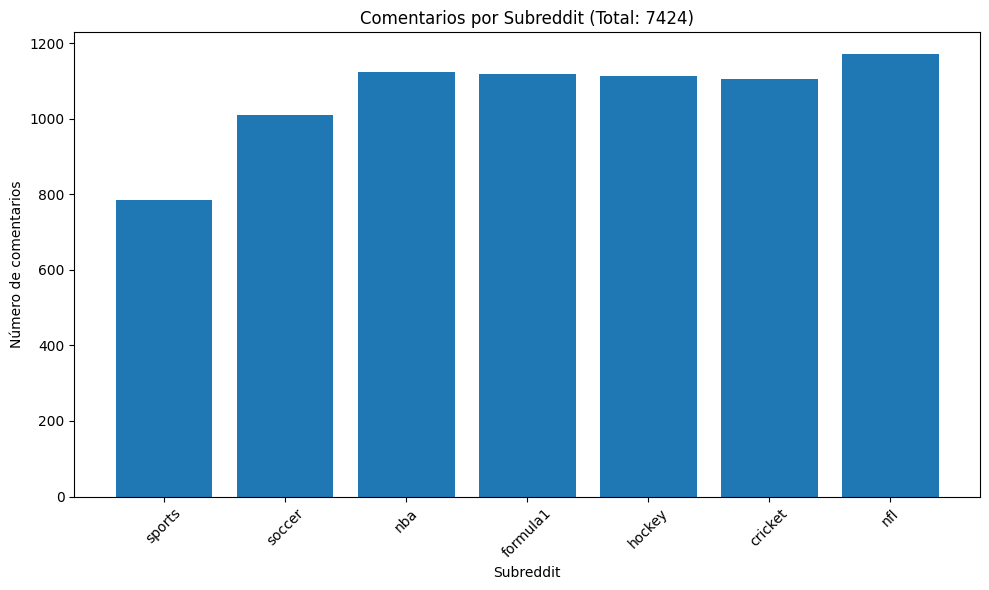

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lista de subreddits
subreddits = ["sports", "soccer", "nba", "formula1", "hockey", "cricket", "nfl"]

# Recopilamos datos
stats = []
total_comments = 0

for subreddit in subreddits:
    try:
        with open(f"comments_{subreddit}.json", "r", encoding="utf-8") as f:
            data = json.load(f)

        thread_count = len(data)
        comment_count = sum(len(thread["comments"]) for thread in data)
        total_comments += comment_count

        stats.append({
            "subreddit": subreddit,
            "hilos": thread_count,
            "comentarios": comment_count,
            "promedio": round(comment_count / thread_count, 2) if thread_count > 0 else 0
        })
    except:
        print(f"No se pudo leer: comments_{subreddit}.json")

# Crear un DataFrame para visualizar mejor
df = pd.DataFrame(stats)
print(f"TOTAL DE COMENTARIOS EXTRAÍDOS: {total_comments}")
display(df)

# Visualización opcional
plt.figure(figsize=(10, 6))
plt.bar(df['subreddit'], df['comentarios'])
plt.title(f'Comentarios por Subreddit (Total: {total_comments})')
plt.xlabel('Subreddit')
plt.ylabel('Número de comentarios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Comprobamos el contenido del conjunto de datos extraido final (`data`):

In [ ]:
data

[{'flair': None,
  'title': '[Thought Experiment] How many draft picks would it take to acquire an Elite Quarterback?',
  'author': 'double0nothing',
  'date': 1746367840.0,
  'score': 0,
  'description': "Let's look at a list of some elite QBs, say:\n\nPatrick Mahomes\n\nJosh Allen\n\nLamar Jackson\n\nJoe Burrow\n\nHow many draft picks would you need to offer for their respective teams to accept the trade?\n\nI was thinking something along the lines of...\n\nMahomes - 6 first round picks\n\nJosh Allen - 5 first round picks\n\nLamar Jackson - 5 first round picks\n\nJoe Burrow - 4 first round picks are a 3rd",
  'comments': [{'user': 'MnVikingsFan34',
    'comment': 'Sure Patrick Ma homes is one of the best quarterbacks of all time but those first round picks could be anything They could even be Patrick Homestead',
    'score': 1,
    'date': 1746368281.0},
   {'user': 'withagrainofsalt1',
    'comment': 'Teams can only trade draft picks from 3 drafts in the future. So 5-6 first round p

In [ ]:
import os
import json

# Lista de subreddits utilizados
subreddits = ["sports", "soccer", "nba", "formula1", "hockey", "cricket", "nfl"]

# Comprobar si los archivos existen y cargarlos
for subreddit in subreddits:
    file_path = f"comments_{subreddit}.json"
    if os.path.exists(file_path):
        print(f"Archivo {file_path} encontrado.")
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            print(f"El archivo {file_path} contiene {len(data)} hilos.")
    else:
        print(f"Archivo {file_path} no encontrado.")


Archivo comments_sports.json encontrado.
El archivo comments_sports.json contiene 104 hilos.
Archivo comments_soccer.json encontrado.
El archivo comments_soccer.json contiene 160 hilos.
Archivo comments_nba.json encontrado.
El archivo comments_nba.json contiene 180 hilos.
Archivo comments_formula1.json encontrado.
El archivo comments_formula1.json contiene 180 hilos.
Archivo comments_hockey.json encontrado.
El archivo comments_hockey.json contiene 180 hilos.
Archivo comments_cricket.json encontrado.
El archivo comments_cricket.json contiene 180 hilos.
Archivo comments_nfl.json encontrado.
El archivo comments_nfl.json contiene 180 hilos.


In [ ]:
# Cargar un archivo JSON de ejemplo
subreddit = "sports"  # ej, esto al nombre de cualquier subreddit
file_path = f"comments_{subreddit}.json"

with open(file_path, "r", encoding="utf-8") as f:
    threads = json.load(f)

# Verificar la estructura de los datos (títulos de hilos y comentarios)
for thread in threads[:5]:  # Mostrar solo los primeros 5 hilos
    print(f"Título del hilo: {thread['title']}")
    print(f"Autor del hilo: {thread['author']}")
    print(f"Flair: {thread['flair']}")
    print(f"Fecha de creación (UTC): {thread['date']}")
    print(f"Puntuación del hilo: {thread['score']}")
    print(f"Descripción: {thread['description'][:200]}...")  # Muestra solo los primeros 200 caracteres
    print("Comentarios:")

    for comment in thread['comments'][:3]:  # Muestra solo los primeros 3 comentarios
        print(f"  - Usuario: {comment['user']}")
        print(f"    Comentario: {comment['comment'][:100]}...")  # Muestra solo los primeros 100 caracteres del comentario
    print("\n---\n")

Título del hilo: 12 year old Vladislav Kozitsyn scored an absolutely filthy shootout goal
Autor del hilo: GreenSnakes_
Flair: :hockey: Hockey
Fecha de creación (UTC): 1746316176.0
Puntuación del hilo: 3078
Descripción: ...
Comentarios:
  - Usuario: TheDiscomfort
    Comentario: That was awesome And those jerseys my god As a Bengals fan and a hockey fan I might need to get ones...
  - Usuario: SinisterCheese
    Comentario: Why is scale so hard to figure out here. At a glance those kids seem and look exactly the same as ad...
  - Usuario: PvtPrimate
    Comentario: I don't know hockey so excuse the terms e Didn't see the self-nutmeg before the shot until the secon...

---

Título del hilo: Woman sues neighbor over basketball hoop in driveway, MN lawsuit says
Autor del hilo: Sandstorm400
Flair: :basketball: Basketball
Fecha de creación (UTC): 1746315340.0
Puntuación del hilo: 364
Descripción: ...
Comentarios:
  - Usuario: jgnp
    Comentario: If I was the neighbor I’d research the sound 

In [ ]:
subreddit = "sports"
file_path = f"comments_{subreddit}.json"

with open(file_path, "r", encoding="utf-8") as f:
    threads = json.load(f)

# Verificar que los comentarios son válidos
invalid_comments_count = 0
for thread in threads:
    for comment in thread['comments']:
        if not is_valid_comment(comment['comment'], min_comment_len, n_words):
            invalid_comments_count += 1

print(f"Número de comentarios no válidos encontrados: {invalid_comments_count}")


Número de comentarios no válidos encontrados: 0


In [ ]:
subreddit = "nfl"
file_path = f"comments_{subreddit}.json"

with open(file_path, "r", encoding="utf-8") as f:
    threads = json.load(f)

# Verificar las fechas de creación de los hilos
dates = [thread['date'] for thread in threads]
dates = [datetime.utcfromtimestamp(date) for date in dates]

# Comprobar si hay hilos de un solo día (o días consecutivos)
min_date = min(dates)
max_date = max(dates)
print(f"Rango de fechas de los hilos: {min_date} - {max_date}")


Rango de fechas de los hilos: 2025-04-30 13:59:30 - 2025-05-04 14:10:40


In [ ]:
# Cargar un archivo JSON de ejemplo
subreddit = "sports"  # Cambia esto al nombre de cualquier subreddit
file_path = f"comments_{subreddit}.json"

with open(file_path, "r", encoding="utf-8") as f:
    threads = json.load(f)

# Verificar que los comentarios tengan puntuaciones válidas
invalid_comments_score = 0
for thread in threads:
    for comment in thread['comments']:
        if comment['score'] < 0:
            invalid_comments_score += 1

print(f"Número de comentarios con puntuación inválida (negativa): {invalid_comments_score}")


Número de comentarios con puntuación inválida (negativa): 106
